# Monitoramento Inteligente de Áreas de Preservação e Supressão Vegetal com Visão Computacional

## Integrantes


- Pedro Leal Murad — RM: 565460
- Murilo Benhossi — RM: 562358
- Jonas Alaf — RM: 566479

## Objetivo

Desenvolver um modelo de Visão Computacional capaz de classificar imagens de satélite em áreas com ocorrência ou risco de incêndio florestal e áreas sem incêndio, apoiando o monitoramento ambiental e a preservação vegetal.

In [ ]:
import tensorflow as tf

print("GPU disponível:", tf.config.list_physical_devices("GPU"))

GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle

from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset

!rm -rf wildfire_dataset
!unzip -q wildfire-prediction-dataset.zip -d wildfire_dataset

Dataset URL: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset
License(s): other
100% 1.45G/1.45G [00:11<00:00, 139MB/s]



In [ ]:
from PIL import Image
import os

def limpar_imagens(base_dir):
    removidas = 0

    for raiz, _, arquivos in os.walk(base_dir):
        for arquivo in arquivos:
            if arquivo.lower().endswith((".jpg", ".jpeg", ".png")):
                caminho = os.path.join(raiz, arquivo)

                try:
                    with Image.open(caminho) as img:
                        img.verify()
                except:
                    os.remove(caminho)
                    removidas += 1

    print(f"Imagens removidas: {removidas}")

limpar_imagens("wildfire_dataset")

Imagens removidas: 0


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
BASE_DIR = "wildfire_dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR = os.path.join(BASE_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Treino:", TRAIN_DIR)
print("Validação:", VALID_DIR)
print("Teste:", TEST_DIR)

Treino: wildfire_dataset/train
Validação: wildfire_dataset/valid
Teste: wildfire_dataset/test


## Análise Exploratória do Dataset

In [ ]:
def contar_imagens(diretorio):
    resultado = {}

    for classe in sorted(os.listdir(diretorio)):
        pasta = os.path.join(diretorio, classe)

        if os.path.isdir(pasta):
            imagens = [
                f for f in os.listdir(pasta)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            resultado[classe] = len(imagens)

    return resultado


print("TREINO")
print(contar_imagens(TRAIN_DIR))

print("\nVALIDAÇÃO")
print(contar_imagens(VALID_DIR))

print("\nTESTE")
print(contar_imagens(TEST_DIR))

TREINO
{'nowildfire': 14500, 'wildfire': 15750}

VALIDAÇÃO
{'nowildfire': 2820, 'wildfire': 3480}

TESTE
{'nowildfire': 2820, 'wildfire': 3480}


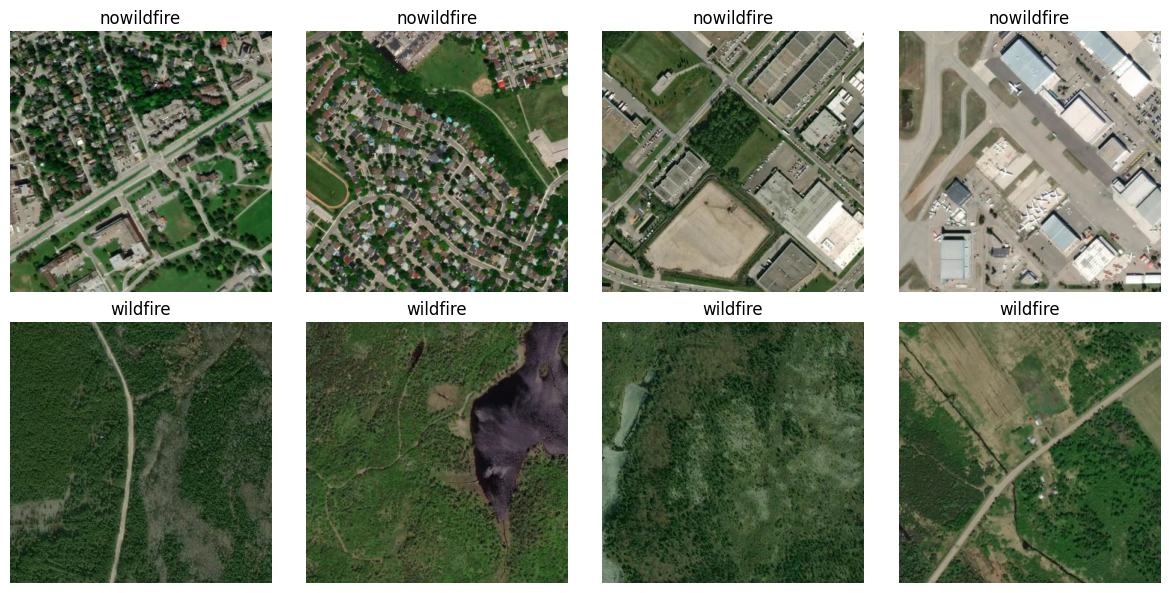

In [ ]:
from tensorflow.keras.utils import load_img

plt.figure(figsize=(12, 6))

classes = ["nowildfire", "wildfire"]
pos = 1

for classe in classes:
    pasta = os.path.join(TRAIN_DIR, classe)

    imagens = [
        img for img in os.listdir(pasta)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for img_nome in random.sample(imagens, 4):
        img = load_img(os.path.join(pasta, img_nome))

        plt.subplot(2, 4, pos)
        plt.imshow(img)
        plt.title(classe)
        plt.axis("off")

        pos += 1

plt.tight_layout()
plt.show()

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Proteção contra imagens JPEG problemáticas
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
valid_ds = valid_ds.apply(tf.data.experimental.ignore_errors())
test_ds = test_ds.apply(tf.data.experimental.ignore_errors())

print("Classe 0 = nowildfire")
print("Classe 1 = wildfire")

Found 30250 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Classe 0 = nowildfire
Classe 1 = wildfire


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset pronto para treinamento.")

Dataset pronto para treinamento.


## Treinamento e Avaliação do Modelo

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "melhor_modelo_wildfire.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=3,
    callbacks=callbacks
)

Epoch 1/3
    945/Unknown 93s 81ms/step - accuracy: 0.9252 - auc: 0.9756 - loss: 0.1869 - precision: 0.9234 - recall: 0.9328

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


945/945 ━━━━━━━━━━━━━━━━━━━━ 113s 103ms/step - accuracy: 0.9423 - auc: 0.9851 - loss: 0.1520 - precision: 0.9384 - recall: 0.9516 - val_accuracy: 0.9641 - val_auc: 0.9935 - val_loss: 0.0983 - val_precision: 0.9716 - val_recall: 0.9632
Epoch 2/3
945/945 ━━━━━━━━━━━━━━━━━━━━ 94s 100ms/step - accuracy: 0.9541 - auc: 0.9904 - loss: 0.1202 - precision: 0.9507 - recall: 0.9617 - val_accuracy: 0.9684 - val_auc: 0.9944 - val_loss: 0.0890 - val_precision: 0.9715 - val_recall: 0.9713
Epoch 3/3
945/945 ━━━━━━━━━━━━━━━━━━━━ 95s 101ms/step - accuracy: 0.9593 - auc: 0.9917 - loss: 0.1108 - precision: 0.9559 - recall: 0.9663 - val_accuracy: 0.9716 - val_auc: 0.9950 - val_loss: 0.0828 - val_precision: 0.9758 - val_recall: 0.9727


## Avaliação do Modelo

In [ ]:
resultado_teste = model.evaluate(test_ds)

for nome, valor in zip(model.metrics_names, resultado_teste):
    print(f"{nome}: {valor:.4f}")

196/196 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.9802 - auc: 0.9979 - loss: 0.0597 - precision: 0.9843 - recall: 0.9797
loss: 0.0597
compile_metrics: 0.9802


In [ ]:
y_true = []
y_prob = []

for imagens, labels in test_ds:

    probs = model.predict(imagens, verbose=0)

    y_prob.extend(probs.ravel())
    y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

print("Previsões geradas.")

Previsões geradas.


In [ ]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc_score:.4f}")

Accuracy : 0.9802
Precision: 0.9843
Recall   : 0.9797
F1 Score : 0.9820
ROC AUC  : 0.9980


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["No Wildfire", "Wildfire"]
    )
)

              precision    recall  f1-score   support

 No Wildfire       0.98      0.98      0.98      2820
    Wildfire       0.98      0.98      0.98      3448

    accuracy                           0.98      6268
   macro avg       0.98      0.98      0.98      6268
weighted avg       0.98      0.98      0.98      6268



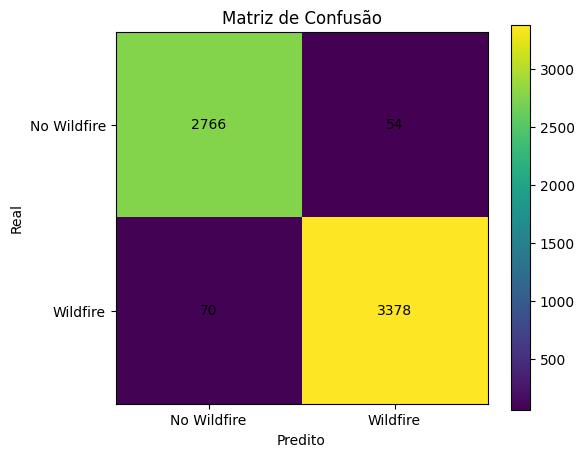

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")

classes = ["No Wildfire", "Wildfire"]

plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

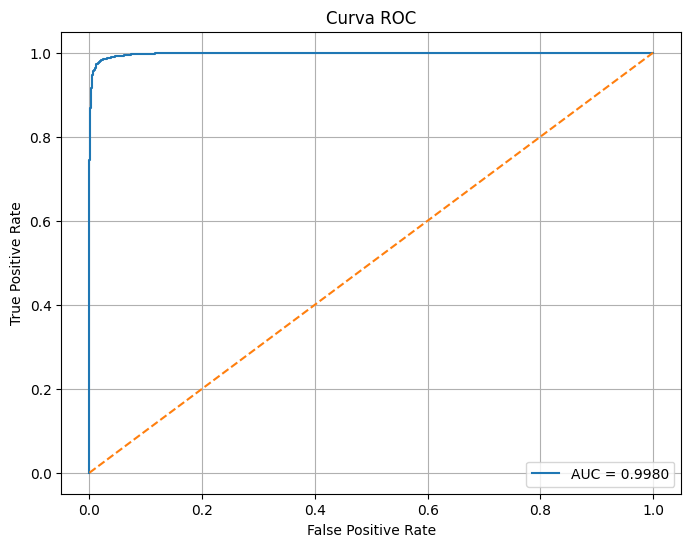

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.grid()

plt.show()

## Conclusão

O modelo EfficientNetB0 apresentou excelente desempenho na classificação de imagens de satélite relacionadas à ocorrência de incêndios florestais.

Os resultados demonstraram alta capacidade de generalização, alcançando valores elevados de acurácia, precisão, recall e ROC AUC, indicando que o modelo consegue identificar corretamente áreas com risco ou ocorrência de incêndio florestal e diferenciá-las de regiões sem ocorrência.

A utilização de Transfer Learning contribuiu significativamente para o desempenho obtido, permitindo o aproveitamento de características visuais previamente aprendidas em grandes bases de imagens.

Como aplicação prática, a solução poderia ser integrada a sistemas de monitoramento ambiental baseados em imagens de satélite, auxiliando órgãos ambientais na detecção precoce de incêndios, fiscalização de áreas de preservação e apoio à tomada de decisão em ações preventivas de proteção ambiental.